# **Mathematics of Financial Markets**

<img style="float: right;" src="https://github.com/torreblanca99/course_financial_applications/blob/develop/docs/img/logo_bourbaki.png?raw=1" width="100"/>

## **Module I:**
#### Topic: Analysis of American Options

##### Name: Julio César Avila Torreblanca


- **Contents**:
    - Notes
    - Code
----


# 📒 Notes

## 1. Monte Carlo Method
The Monte Carlo method is an immediate application of the Law of Large Numbers, it consists of the following steps to calculate a parameter $\mu$:

1. Define independent and identically distributed (i.i.d.) random variables whose expectation coincides with $\mu$.
2. Construct a sample of arbitrary size $n$ from these random variables.
3. Thanks to the Law of Large Numbers, the empirical average of this sample will increasingly approach $\mu$ as $n \to \infty$.

Mathematical Formula (Approximating the Expected Value of a Function): If $g$ is a function and $X$ is a random variable with distribution $F$, then if $\mu_g = \mathbb{E}[g(X)]$ is well-defined, the Law of Large Numbers states:

$$ \frac{g(X_1) + \cdots + g(X_n)}{n} \to \mu_g \quad \text{as } n \to \infty $$

Where:
- $g$: a function whose expected value is being approximated.
- $X$: a random variable with distribution $F$.
- $\mu_g$: the expected value of $g(X)$.
- $X_1, \ldots, X_n$: an independent and identically distributed random sample from $F$.
- $n$: the sample size (number of observations).


## 2. Approximating European Option Prices
The price of a European call option can be expressed as the expected value of the contract at expiration, discounted to present value using the risk-free rate, under the martingale measure.

Mathematical Formula (European Call Option Price):

$$ c = e^{-rT}\mathbb{E}[\max(S_T - K, 0)] $$

Where the underlying asset price at maturity $S_T$ is often modeled such that $\log(S_T) \sim \mathcal{N}(\log(S_0) + [r - \frac{1}{2}\sigma^2]T)$.

Equivalently, $S_T$ can be expressed as:

$$ S_T = S_0 \exp\left\{ \left[r - \frac{1}{2}\sigma^2\right] T + \sigma\sqrt{T}Z \right\} $$

Where:
- $c$: the price of the European call option.
- $e$: Euler's number (the base of the natural logarithm).
- $r$: the risk-free interest rate.
- $T$: the time to maturity (expiration date).
- $\mathbb{E}[\cdot]$: the expected value operator, specifically under the risk-neutral (martingale) measure.
- $\max(\cdot, 0)$: ensures the payoff is non-negative, representing the intrinsic value of the option at expiration.
- $S_T$: the price of the underlying asset at expiration $T$.
- $K$: the strike price.
- $S_0$: the initial price of the underlying asset.
- $\sigma$: the volatility of the underlying asset's price.
- $Z$: a standard normal random variable ($Z \sim \mathcal{N}(0, 1)$).

Approximation Steps using Monte Carlo:

1. Generate observations: Generate $n$ independent observations $Z_1, \ldots, Z_n$ from a standard normal distribution ($\mathcal{N}(0, 1)$). Use these to simulate $n$ possible stock prices at expiration:

$$ S_T^j = S_0 \exp\left\{ \left[r - \frac{1}{2}\sigma^2\right] T + \sigma\sqrt{T}Z_j \right\} \quad \text{for } 1 \leq j \leq n $$

2. Calculate average payoff: By the Law of Large Numbers, the average of the discounted payoffs from these simulations will converge to the option's price: $$ \frac{\max(S_T^1 - K, 0) + \max(S_T^2 - K, 0) + \cdots + \max(S_T^n - K, 0)}{n} \to c \quad \text{as } n \to \infty $$ This average then needs to be discounted back by $e^{-rT}$ to get the option's current price.

## 3. American Options and the Longstaff-Schwartz Algorithm

Definition (American Option): An American option is a contract that gives its owner the right, but not the obligation, to buy (for a call) or sell (for a put) an underlying asset at a predetermined strike price $K$ at any time $t$ on or before the expiration date $T$ ($0 \leq t \leq T$). This contrasts with European options, which can only be exercised at expiration.

Longstaff-Schwartz Algorithm: The Longstaff-Schwartz algorithm is a refinement of the Monte Carlo method specifically designed to value American options. It addresses the challenge of early exercise by combining Monte Carlo simulation with linear regression.

Challenge: Unlike European options, American options allow for early exercise, meaning the optimal exercise time $\tau$ is not necessarily fixed at $T$. This introduces a supremum into the valuation formula, which means the standard Monte Carlo method cannot be directly applied to find the option's price. The Longstaff-Schwartz algorithm provides an indirect method to overcome this.

## 4. The Concept of Option
Definition (Option): An option is a financial security that grants its owner the right (but not the obligation) to perform a specific transaction (buy or sell) involving a fixed number of shares of a specified common stock at a fixed price (the striking price) on or before a given expiration date. Essentially, options can be seen as a form of "financial insurance" that secures the purchase or sale price of an asset.

Key Characteristics:
- Underlying Asset (S): The asset on which the option is based (e.g., stock, commodity).
- Striking Price (K): The fixed price at which the owner can buy or sell the underlying asset.
- Expiration Date (T): The specific date by which the option must be exercised, or it expires worthless (also known as maturity).

Types of Options:
- Based on Exercise Right:
    - Call Option ($\boldsymbol{c}$): Grants the owner the right to buy the underlying asset at the strike price $K$.
        - Payoff at Expiration ($t=T$): $$ \Phi_c(S_T) = \max(S_T - K, 0) $$
            - $S_T$: Price of the underlying asset at expiration.
            - If $S_T > K$, the option is "in-the-money," and the owner profits by buying at $K$ and selling at $S_T$.
            - If $S_T \leq K$, the option expires worthless.
    - Put Option ($\boldsymbol{p}$): Grants the owner the right to sell the underlying asset at the strike price $K$.
         Payoff at Expiration ($t=T$): $$ \Phi_p(S_T) = \max(K - S_T, 0) $$
            - $S_T$: Price of the underlying asset at expiration.
            - If $S_T < K$, the option is "in-the-money," and the owner profits by selling at $K$ an asset worth $S_T$.
            - If $S_T \geq K$, the option expires worthless.
- Based on Exercise Time:
    - European Option: Can only be exercised at time $T$ (expiration).
    - American Option: Can be exercised at any time $t$ up to and including $T$ ($0 \leq t \leq T$).
    - Bermuda Option: Can be exercised at specific, pre-established times $t_1, t_2, \ldots, t_n$ where $0 \leq t_1 \leq t_2 \leq \cdots \leq T$.
    - Asian Option: The payoff depends on the average price of the underlying asset over a period, rather than its price at a single point in time.\

Put-Call Parity: At expiration ($t=T$), a fundamental relationship exists between European call and put options with the same strike price and expiration date: $$ \Phi_c(S_T) = \Phi_p(S_T) + S_T - K $$ This relationship is derived from no-arbitrage principles.

## 5. The Fundamental Theorem of Option Valuation
This theorem guarantees a method for pricing options, particularly important for linking discrete models to continuous ones and for Monte Carlo applications.

For a European Put Option: The value of a European put option $V(A, t)$ at time $t$ can be expressed as the expected value of its payoff at maturity $T$, discounted back to time $t$ using the risk-free rate $r$, under a specific probability measure $Q$ (known as the risk-neutral or martingale measure).

Mathematical Formula (European Put Option):

$$ V(A, t) = \mathbb{E}_Q [\max{0, K - X_T} \cdot e^{-r(T-t)}] $$

Where:
- $V(A, t)$: the value of the option (on asset $A$) at current time $t$.
- $\mathbb{E}_Q[\cdot]$: the expected value under the risk-neutral probability measure $Q$.
- $\max{0, K - X_T}$: the payoff of the put option at maturity $T$.
- $K$: the strike price.
- $X_T$: the price of the underlying asset at maturity $T$.
- $e^{-r(T-t)}$: the discount factor, where $r$ is the risk-free interest rate and $(T-t)$ is the time remaining until maturity.

For an American Put Option: While a similar result exists for American options, the presence of the early exercise right complicates direct application of the Monte Carlo method. The value $V(A, t)$ is given by the supremum (the least upper bound) of the expected discounted payoff over all possible exercise times $\tau$ between the current time $t$ and the maturity $T$.

Mathematical Formula (American Put Option):
$$ V(A, t) = \sup_{\tau \in [t,T]} \mathbb{E}Q [\max{0, K - X\tau} \cdot e^{-r(\tau-t)}] $$

Where:
- $\sup_{\tau \in [t,T]}$: the supremum taken over all possible exercise times $\tau$ within the interval $[t, T]$.
- $X_\tau$: the price of the underlying asset at the exercise time $\tau$.
- Other variables are as defined for the European put option.

Implication: This fundamental difference (the supremum over exercise times) means that a direct Monte Carlo simulation (which averages payoffs at a fixed future point) cannot be used for American options. Instead, more sophisticated indirect methods, such as the Longstaff-Schwartz algorithm, are required to determine the optimal exercise strategy and thus the option's value.

---

# Coding


# 1. Libraries and Parameters


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 2. Simulation

In [2]:
def simulate_prices(initial_price, interest_rate, sigma, T, paths):
    '''The function returns a dataframe where each row corresponds to the
    simulation of the price trajectory, under the hypothesis that the price
    of the asset follows a Geometric Brownian Motion, starting with the
    initial price at t = 0, in the first column and t = T in the last.

    * initial_price: Initial price of the asset, when the option is signed
    * interest_rate: Interest rate considered for the term of the option
    * sigma: volatility (standard deviation) of the asset price in a
             previous period
    * T: term in days of the option
    * paths: number of simulations of the price trajectory'''

    # We create a matrix of zeros of size T+1, paths.
    np.random.seed(1)
    PriceMatrix = np.zeros((paths, T + 1), dtype = np.float64)
    # We place the initial price in the first row (day 0)
    PriceMatrix[:,0] = initial_price



    #Geometric Brownian Motion to calculate the price value at each t starting from t = 0
    for i in range(1, T + 1):
        #we start with a random variable normal distribution in each of the trajectories to simulate
        Z = np.random.standard_normal(size = paths)
        weiner_process = sigma * Z / np.sqrt(365)  #weiner_process or brownian motion
        PriceMatrix[:, i] = (PriceMatrix[:, i - 1] * np.exp((interest_rate - sigma ** 2 / 2.) * 1 / 365 + weiner_process ))  # eq. (1.5) Gustafsson (2015)

    return pd.DataFrame(PriceMatrix, index=['simulation_'+ str(row) for row in range(1, paths+1)])


In [3]:
def LSM(initial_price, interest_rate, sigma, T, paths, strike_price, option_type='put'):
    ''' The function calculates the value of an option. To do this, it calls the
    simulate_prices function to generate the asset price trajectories, which are used
    to calculate profit scenarios considering the strike price. Finally, a value matrix
    is constructed by calculating the conditional expectation of the profit from keeping
    the option alive at each exercise opportunity using polynomial regression by least squares.'''

    assert option_type == 'call' or option_type == 'put', "option type can only be 'call' or 'put'"

    # Step 1. Creation of Price Matrix
    df_prices = simulate_prices(initial_price, interest_rate, sigma, T, paths)
    PriceMatrix = df_prices.values

    # STEP 2. Creation of Profit Matrix
    if option_type == 'call':
       Profit = np.maximum(PriceMatrix - strike_price,
                           np.zeros((paths, T + 1), dtype=np.float64))
    elif option_type == 'put':
       Profit = np.maximum(strike_price - PriceMatrix,
                           np.zeros((paths, T + 1), dtype=np.float64))

    # STEP 3. Creation of Value Matrix
    ValueMatrix = np.zeros_like(Profit)
    ValueMatrix[:,-1] = Profit[:,-1]

    # Polynomial regression by least squares (order 2)
    discount = np.exp(-interest_rate*T/365)
    for t in range(T - 1, 0, -1):
        coefficients = np.polyfit(PriceMatrix[:, t], ValueMatrix[:, t + 1] * discount, 2)
        continuation_value = np.polyval(coefficients, PriceMatrix[:, t])
        # Evaluate if the Profit is greater than the value of continuing
        ValueMatrix[:, t] = np.where(Profit[:, t] > continuation_value,
                                     Profit[:, t], ValueMatrix[:, t + 1] * discount)
    # STEP 4. The value of the option is evaluated at time 0 of the Value Matrix

    option_value_t0 = ValueMatrix[:,1]*discount

    return np.mean(option_value_t0)


In [5]:
## load data
price = pd.read_csv('https://raw.githubusercontent.com/AnIsAsPe/LSM-Opciones-americanas/main/Datos/Precios%20Azucar%202020.csv',
                     usecols=['Date', 'Close'], parse_dates=['Date'], index_col = 'Date').dropna()
price = price['Close']

price.head()


,Close
Date,
2020-01-02,13.13
2020-01-03,13.31
2020-01-06,13.73
2020-01-07,13.59
2020-01-08,13.47


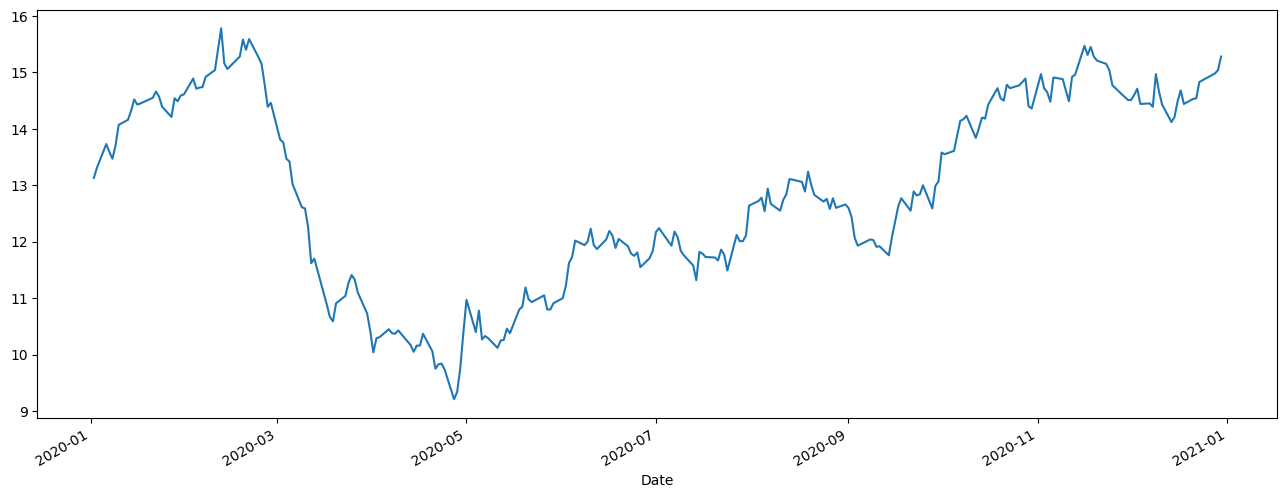

In [6]:
price.plot(figsize=(16,6))
plt.show()

### Monte Carlo simulation: one year price paths (interest rate: 6%)

In [9]:
price_ini = price[-1]
sigma = np.std(price)

print(f'Initial price: {price_ini}')
print(f'Volatility: {sigma}')

Initial price: 15.28
Volatility: 1.6802378669700317


/tmp/ipython-input-125763697.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  price_ini = price[-1]


In [11]:
# Considering the same number of days as in 2020, we run the Monte Carlo simulation of a Brownian process
rate = 0.06
days = 30
n = 150000

Prices_df = simulate_prices(price_ini, rate, sigma, days, n)
Prices_df.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
simulation_1,15.28,17.561327,16.231503,16.597065,16.680372,15.537294,15.960361,17.325719,20.336025,22.514823,...,22.492421,22.597242,26.401440,27.969662,28.016856,28.659543,29.699588,32.871778,27.848593,29.511507
simulation_2,15.28,14.426102,15.506855,14.123505,13.364882,14.108793,15.143849,15.091583,12.946440,12.651010,...,9.231304,8.560340,7.987191,7.693249,7.757886,7.262922,6.800958,6.668809,7.517860,6.773376
simulation_3,15.28,14.532540,15.991096,15.531001,13.844871,13.644119,14.104036,13.229828,13.652552,13.188685,...,17.341956,18.667045,17.475841,19.019439,19.222673,19.631608,19.249886,21.289730,23.225997,24.254033
simulation_4,15.28,13.852652,12.822144,13.719303,13.364764,14.803389,16.156495,15.981509,16.291039,16.079470,...,13.934084,14.033176,14.329727,14.252236,12.936798,11.989991,14.931941,16.558487,21.268675,18.864235
simulation_5,15.28,16.427428,15.665354,17.728493,15.049232,14.900170,13.983552,13.031052,14.452635,16.084611,...,6.561264,6.335870,5.565021,6.060038,5.607180,4.658791,5.249767,5.278541,4.727568,5.432962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
simulation_149996,15.28,14.087027,12.126533,11.618523,12.334194,11.796876,11.615107,11.412306,10.900237,14.799714,...,6.387396,6.685755,6.259263,6.150894,6.241907,5.975696,6.365051,6.071113,5.206422,4.780215
simulation_149997,15.28,15.596889,14.900218,14.519553,13.676196,14.192995,13.817127,13.766385,14.516640,11.703306,...,8.782320,8.911542,8.651974,8.395797,9.483373,11.907212,11.925066,11.145515,10.409914,12.111319
simulation_149998,15.28,13.944811,14.213770,13.659506,15.019265,15.473107,15.268104,14.393948,13.815025,13.489066,...,8.667522,8.124743,7.532588,7.430078,6.970608,6.354635,6.960693,6.425539,6.409292,6.477771
simulation_149999,15.28,13.993963,14.475954,17.150135,16.931046,16.920038,16.835497,16.804310,16.781108,16.252710,...,11.313708,10.853041,10.011382,10.163345,10.390218,8.887057,8.557226,7.557117,7.617498,6.750637


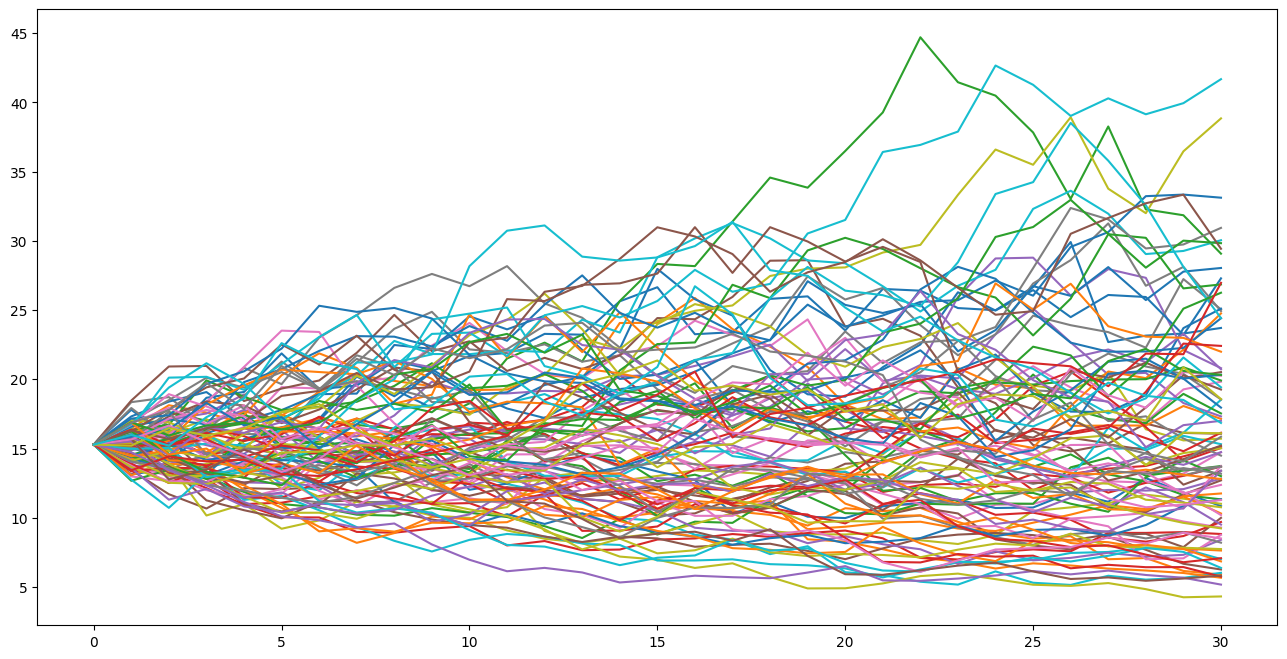

In [13]:
sample = np.random.choice(Prices_df.index, 100)
Prices_df.transpose()[sample].plot(figsize=(16, 8), legend=False)
plt.show()

### Construction of the Payoff Matrix

In [14]:
Prices_df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
simulation_1,15.28,17.561327,16.231503,16.597065,16.680372,15.537294,15.960361,17.325719,20.336025,22.514823,...,22.492421,22.597242,26.401440,27.969662,28.016856,28.659543,29.699588,32.871778,27.848593,29.511507
simulation_2,15.28,14.426102,15.506855,14.123505,13.364882,14.108793,15.143849,15.091583,12.946440,12.651010,...,9.231304,8.560340,7.987191,7.693249,7.757886,7.262922,6.800958,6.668809,7.517860,6.773376


In [15]:
# Calculate Payoff Matrix for "put" options
# 0 if the price is greater than or equal to the strike
Strike = 14
Payoff = np.maximum(Strike - Prices_df.values, np.zeros((n, days + 1), dtype=np.float64))
pd.DataFrame(Payoff, index = Prices_df.index).iloc[:, -5:]

,26,27,28,29,30
simulation_1,0.000000,0.000000,0.000000,0.000000,0.000000
simulation_2,6.737078,7.199042,7.331191,6.482140,7.226624
simulation_3,0.000000,0.000000,0.000000,0.000000,0.000000
simulation_4,2.010009,0.000000,0.000000,0.000000,0.000000
simulation_5,9.341209,8.750233,8.721459,9.272432,8.567038
...,...,...,...,...,...
simulation_149996,8.024304,7.634949,7.928887,8.793578,9.219785
simulation_149997,2.092788,2.074934,2.854485,3.590086,1.888681
simulation_149998,7.645365,7.039307,7.574461,7.590708,7.522229
simulation_149999,5.112943,5.442774,6.442883,6.382502,7.249363


### Construction of the Value Matrix

In [16]:
ValueMatrix = np.zeros_like(Payoff)
ValueMatrix[:, -1] = Payoff[:, -1]  # start at the last day
discount = np.exp(-rate * days / 365)

# Polynomial regression by least squares to calculate the continuation value
for t in range(days - 1, 0, -1):  # from the second-to-last day
    x = Prices_df.iloc[:, t]
    y = ValueMatrix[:, t + 1] * discount
    # find the coefficients
    coefficients = np.polyfit(x, y, 2)
    continuation_value = np.polyval(coefficients, x)
    # When the payoff at time t is greater than the continuation value,
    ValueMatrix[:, t] = np.where(Payoff[:, t] > continuation_value,
                                 Payoff[:, t],
                                 ValueMatrix[:, t + 1] * discount)

pd.DataFrame(ValueMatrix, index = Prices_df.index)  #.iloc[:, -5:]


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
simulation_1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
simulation_2,0.0,4.320810,4.342171,4.363637,4.385209,4.406888,4.428675,4.450569,4.472571,4.494682,...,4.768696,5.439660,6.012809,6.306751,6.242114,6.737078,7.199042,7.331191,6.482140,7.226624
simulation_3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
simulation_4,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
simulation_5,0.0,5.494485,5.521648,5.548946,5.576378,5.603946,5.631650,5.659491,5.687470,5.715587,...,7.438736,7.664130,8.434979,7.939962,8.392820,9.341209,8.750233,8.721459,9.272432,8.567038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
simulation_149996,0.0,4.475254,4.497378,4.519611,4.541955,4.564409,4.586974,4.609651,4.632439,4.655341,...,7.612604,7.314245,7.740737,7.849106,7.758093,8.024304,7.634949,7.928887,8.793578,9.219785
simulation_149997,0.0,4.166365,4.186962,4.207661,4.228462,4.249366,4.270374,4.291485,4.312701,4.334022,...,5.217680,5.088458,5.348026,5.604203,4.516627,1.851790,1.860945,1.870145,1.879390,1.888681
simulation_149998,0.0,4.355654,4.377187,4.398826,4.420573,4.442427,4.464389,4.486459,4.508639,4.530928,...,5.332478,5.875257,6.467412,6.569922,7.029392,7.645365,7.039307,7.574461,7.590708,7.522229
simulation_149999,0.0,4.519890,4.542234,4.564690,4.587256,4.609934,4.632724,4.655627,4.678643,4.701773,...,4.988412,5.013073,5.037857,5.062762,5.087791,5.112943,5.442774,6.442883,6.382502,7.249363


In [17]:
option_value_t0 = np.mean(ValueMatrix[:, 1] * discount)
option_value_t0

np.float64(1.8417937871667767)

# Join ALL

In [18]:
price_ini, Strike, sigma, rate, days, n

(np.float64(15.28), 14, 1.6802378669700317, 0.06, 30, 150000)

In [20]:
LSM(price_ini, rate, sigma, days, n,  17, 'put')  # el comprador de la opción tiene derecho
                                                   # vender al precio Strike
                                                   # el vendedor de la opción tiene la
                                                   # obligacion de comprar al precio del Strike

np.float64(3.505199219136325)

In [21]:
LSM(price_ini, rate, sigma, days, n, 17, 'call')  # el comprador de la opción tiene derecho
                                                   # comprar al precio Strike
                                                   # el vendedor de la opción tiene la
                                                   # obligacion de vender al precio del Strike

np.float64(1.9905516500259133)